In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.0f}".format)

# Loading the tables

In [3]:
# Survey responses
survey_data = pd.read_parquet("../data/survey/survey_cleaned.parquet")

# Maintenance and restrictions schema
maintenance_dfs = {}
maintenance_folder = Path("../data/operational/maintenance_and_restrictions")
for file in maintenance_folder.glob("*.parquet"):
    name = file.stem
    maintenance_dfs[name] = pd.read_parquet(file)

# Train service schema
service_dfs = {}
service_folder = Path("../data/operational/train_service_foundation")
for file in service_folder.glob("*.parquet"):
    name = file.stem
    service_dfs[name] = pd.read_parquet(file)

cleaning_df = pd.read_parquet("../data/operational/cleaning_inspections.parquet")
date_df = pd.read_parquet("../data/operational/dim_date_base.parquet")
t15_df = pd.read_parquet("../data/operational/t15_data.parquet")
arrival_df = pd.read_excel("../data/operational/Arrival delay - 20250101-20260531.xlsx")
departure_df = pd.read_excel("../data/operational/Departure delay - 20250101-20260531.xlsx")
turnaround_df = pd.read_excel("../data/operational/Rotations - 20250101-20260531.xlsx")
checkin_df = pd.read_csv("../data/customer information/202605221728_dmt_no_pii_checkin_records_20250101-20260522.csv")

c:\Users\Vincent\anaconda3\envs\eurostar-thesis\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\Vincent\anaconda3\envs\eurostar-thesis\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\Vincent\anaconda3\envs\eurostar-thesis\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## Central train service table

In [4]:
dim_train_service = service_dfs['dim_train_service'] # central table

In [5]:
print(f"Central table size: {len(dim_train_service)}")
print(f"Starting date of all train_services: {dim_train_service['destination_theoretical_time'].min()}")

Central table size: 94221
Starting date of all train_services: 2025-01-01 09:30:00+00:00


In [6]:
dim_train_service = dim_train_service[dim_train_service['is_cancelled_flag'] == False] # filter out only completed train services
dim_train_service = dim_train_service[dim_train_service['service_type'] == 'COMMERCIAL'] # filter out only commercial train services
dropped_service_columns = ['axis_id', 'an_id', 'date_id', 'train_operator', 'origin_point_id', 'destination_point_id', 'cancelled_date_ts', 'is_excluded_flag', 'is_always_on_time_flag', 'is_forced_flag', 'is_cancelled_flag', 'service_type']
dim_train_service.drop(columns = dropped_service_columns, inplace = True) # drop irrelevant columns

In [7]:
dim_train_service['diagram_id'].unique()

array(['E002', 'K001', 'K002', 'K012', 'K006', 'K005', 'K003', 'K008',
       'K011', 'K004', 'K013', 'K117', 'K114', 'K112', 'K107', 'K110',
       'K108', 'K109', 'K115', 'K111', 'K116', 'K113', 'K009', 'Y007',
       'Y003', 'Y004', 'Y008', None, 'O009', 'O007', 'Y006', 'Y005',
       'Y002', 'Y001', 'K010', 'K015', 'K016', 'O014', 'O013', 'K007',
       'O010', 'O008', 'O005', 'O004', 'O001', 'O002', 'O006', 'O003',
       'Y009', 'K014', 'O011', 'O018', 'O012', 'Y010', 'E001', 'E003',
       'E009', 'E005', 'E004', 'E010', 'O015', 'O019', 'E006', 'O020',
       'K018', 'E007', 'O017', 'Y011', 'O016', 'K020', 'E008', 'K019',
       'K017', 'Y012'], dtype=object)

In [8]:
dim_train_service['trainset'].unique()

array(['3212-3211', '4302', '4346', '4342', '4322', '4332', '4306',
       '4307', '4303', '4301', '4344', '4304', '4321', '4305', '4533',
       '4536', '4537', '4534', '4341', '4539', '4331', '4535', '4538',
       '4540', None, '4007-4008', '4015-4016', '4345', '4532', '4343',
       '4017-4018', '4026-4025', '4031-4032', '4027-4028', '4014-4013',
       '4001-4002', '4019-4020', '4030-4029', '4009-4010', '4003-4004',
       '4034-4033', '4006-4005', '4021-4022', '4024-4023', '4029-4030',
       '4032-4031', '4023-4024', '4008-4007', '4033-4034', '4011-4012',
       '4018-4017', '4012-4011', '4013-4014', '4028-4027', '4020-4019',
       '4016-4015', '4025-4026', '4002-4001', '4005-4006', '4004-4003',
       '-', '3220-3219', '3206-3205', '3016-3015', '3230-3229',
       '3221-3222', '3219-3220', '3211-3212', '3008-3007', '3015-3016',
       '3205-3206', '3007-3008', '3229-3230', '3222-3221', '4022-4021',
       '4010-4009'], dtype=object)

In [9]:
dim_train_service = (
    dim_train_service
    .assign(trainset=dim_train_service["trainset"].str.split("-"))
    .explode("trainset")
    .reset_index(drop=True)
)

# Drop empty/whitespace-only train set numbers (from rows that were just "-")
dim_train_service = dim_train_service.loc[
    dim_train_service["trainset"].str.strip().ne("")
].reset_index(drop=True)

dim_train_service.drop(columns= ['travel_date_dt', 'od', 'diagram_id'], inplace=True)
dim_train_service = dim_train_service.dropna(subset=['trainset'])

In [10]:
dim_train_service['trainset'].unique()

array(['3212', '3211', '4302', '4346', '4342', '4322', '4332', '4306',
       '4307', '4303', '4301', '4344', '4304', '4321', '4305', '4533',
       '4536', '4537', '4534', '4341', '4539', '4331', '4535', '4538',
       '4540', '4007', '4008', '4015', '4016', '4345', '4532', '4343',
       '4017', '4018', '4026', '4025', '4031', '4032', '4027', '4028',
       '4014', '4013', '4001', '4002', '4019', '4020', '4030', '4029',
       '4009', '4010', '4003', '4004', '4034', '4033', '4006', '4005',
       '4021', '4022', '4024', '4023', '4011', '4012', '3220', '3219',
       '3206', '3205', '3016', '3015', '3230', '3229', '3221', '3222',
       '3008', '3007'], dtype=object)

In [11]:
len(dim_train_service)

78744

In [12]:
dim_train_service['origin_theoretical_time'].head()

0   2025-04-30 10:56:00+00:00
1   2025-04-30 10:56:00+00:00
2   2025-09-06 16:44:00+00:00
3   2025-02-20 11:53:00+00:00
4   2025-09-29 10:44:00+00:00
Name: origin_theoretical_time, dtype: datetime64[us, UTC]

In [13]:
dim_train_service.head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time
0,9123_20250430,9123,3212,E300,Channel,2025-04-30 10:56:00+00:00,2025-04-30 11:57:00+00:00
1,9123_20250430,9123,3211,E300,Channel,2025-04-30 10:56:00+00:00,2025-04-30 11:57:00+00:00
2,9474_20250906,9474,4302,TGH,Continental,2025-09-06 16:44:00+00:00,2025-09-06 20:15:00+00:00
3,9435_20250220,9435,4346,TGH,Continental,2025-02-20 11:53:00+00:00,2025-02-20 16:16:00+00:00
4,9438_20250929,9438,4342,RUB,Continental,2025-09-29 10:44:00+00:00,2025-09-29 14:09:00+00:00


In [14]:
dim_train_service['train_service'] = dim_train_service['train_service'].astype(int)
dim_train_service['trainset'] = dim_train_service['trainset'].astype(int)

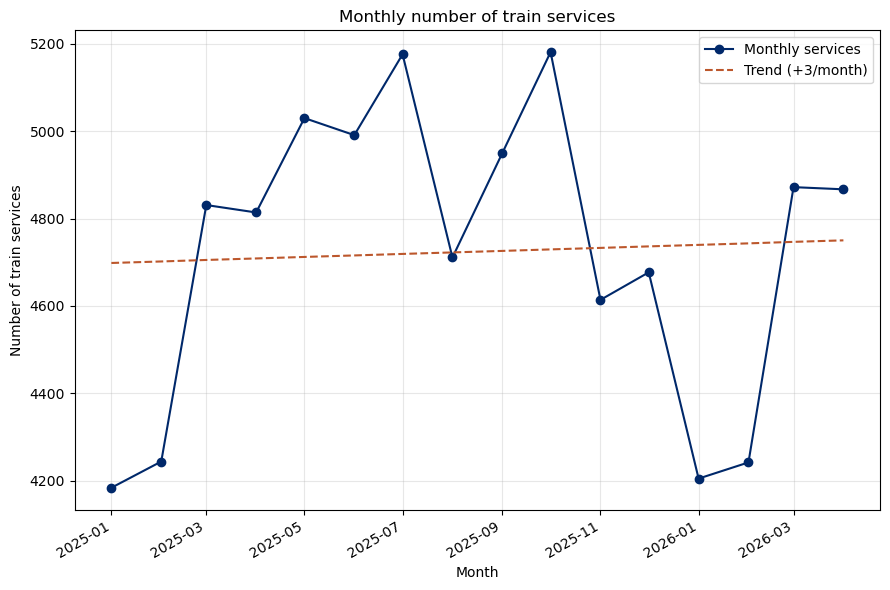

In [20]:
import matplotlib.pyplot as plt

monthly_services = (
    dim_train_service
    .set_index('origin_theoretical_time')
    .resample('MS')['train_service']
    .count()
)

# Drop the last (incomplete) month: May 2026
monthly_services = monthly_services[monthly_services.index < '2026-05-01']

# Trend line (linear fit over month index)
x = np.arange(len(monthly_services))
coeffs = np.polyfit(x, monthly_services.values, 1)
trend = np.poly1d(coeffs)(x)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(monthly_services.index, monthly_services.values, marker='o', label='Monthly services', color='#00286a')
ax.plot(monthly_services.index, trend, '--', color='#bc572c',
        label=f'Trend ({coeffs[0]:+.0f}/month)')
ax.set_title('Monthly number of train services')
ax.set_xlabel('Month')
ax.set_ylabel('Number of train services')
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# Linking restrictions to train service

In [15]:
fct_restrictions = maintenance_dfs['fct_restrictions']
len(fct_restrictions)

2348

In [16]:
fct_restrictions.head()

,intervention_nk,trainset_sk,fleet_sk,raised_at_depot_sk,closed_at_depot_sk,category_sk,intervention_type_sk,component_sk,intervention_created_date_sk,intervention_created_time,restriction_created_date_sk,restriction_created_time,restriction_closed_date_sk,restriction_closed_time,trainset_number,vehicle_number,raised_at_depot_nk,closed_at_depot_nk,intervention_type_nk,category_nk,sub_category_nk,component_code_nk,intervention_description,intervention_comment,intervention_creator,restriction_description,restriction_handler,is_closed,is_continental,is_hvac,days_open
0,810424048,19,7,4,10,4,7,9,20221225,02:48,20221225,02:48,20260325,14:00,3999,373220,ztm,Unknown,OEXS,RESTRICTION_CATEGORY_TECHNICAL,RESTRICTION_SUB_CATEGORY_BSM,M1,Inapte BSM,None,CAMPBELL,Inapte BSM as per FPTR-003.,campbell,Yes,No,No,1186
1,810881447,57,6,8,4,20,7,5,20231124,13:05,20231124,13:05,20260325,14:04,3220,373999,lo.,ztm,OEXS,RESTRICTION_CATEGORY_UNSPECIFIED,RESTRICTION_SUB_CATEGORY_UNSPECIFIED,R9,DGN3634 \nPC3999 is not allowed to run in snow...,None,PLANNING,"3999 PC 2023,2024 Winterisation campaign not d...",planning,Yes,No,No,852
2,811087109,19,7,4,10,20,7,9,20240413,03:45,20240413,03:45,20260325,14:00,3999,373220,ztm,Unknown,OEXS,RESTRICTION_CATEGORY_UNSPECIFIED,RESTRICTION_SUB_CATEGORY_UNSPECIFIED,M1,SSI 098 VERSION B- LIFEGUARD CHECKS TO BE CARR...,None,FC,SSI098-B LIFEGUARD CHECKS EACH ESN WR396787,FC,Yes,No,No,711
3,811569599,151,4,8,4,20,7,30,20250226,03:16,20250226,03:16,20260402,00:43,4005,3740055,lo.,ztm,OEXS,RESTRICTION_CATEGORY_UNSPECIFIED,RESTRICTION_SUB_CATEGORY_UNSPECIFIED,MC05,DGN3170 - 27/03/26 MC05 EPCU RPL b4 1.6M KM PO...,DGN3170C MC05 EPCU RP B4 1.6M POST R1 DUE TO C...,CLARK,DGN3170 EPCU RPL B4 1.7M KM 27/03/26 23:59,CLARK,Yes,No,No,400
4,811569682,43,4,8,4,20,7,30,20250226,04:19,20250226,04:19,20260402,00:54,4006,3740065,lo.,ztm,OEXS,RESTRICTION_CATEGORY_UNSPECIFIED,RESTRICTION_SUB_CATEGORY_UNSPECIFIED,MC05,DGN3170 - 27/03/26 MC05 EPCU TO RPL B4 1.6M KM...,DGN3170C MC05 EPUC TO BE RPL B4 1.6M KM POST R...,CLARK,DGN3170 MC05 EPCU RPL B4 1.7M KM OR 27/03/26 2...,CLARK,Yes,No,No,400


In [17]:
fct_restrictions = fct_restrictions[fct_restrictions['category_nk'] == 'RESTRICTION_CATEGORY_COMFORT']

In [18]:
fct_restrictions['sub_category_nk'].unique()

array(['RESTRICTION_SUB_CATEGORY_AIRCO',
       'RESTRICTION_SUB_CATEGORY_FRIDGE', 'RESTRICTION_SUB_CATEGORY_WC',
       'RESTRICTION_SUB_CATEGORY_WIFI',
       'RESTRICTION_SUB_CATEGORY_HEATING',
       'RESTRICTION_SUB_CATEGORY_WINDOW'], dtype=object)

In [19]:
dim_restriction_category = maintenance_dfs['dim_restriction_category']
len(dim_restriction_category)

21

In [20]:
dim_restriction_category = dim_restriction_category[dim_restriction_category['category_display'] == 'Comfort']

In [21]:
dim_restriction_category

,category_sk,sub_category_nk,category_nk,category_display,sub_category_display,is_hvac,is_curated
2,2,RESTRICTION_SUB_CATEGORY_AIRCO,RESTRICTION_CATEGORY_COMFORT,Comfort,Air Conditioning,Yes,Yes
3,7,RESTRICTION_SUB_CATEGORY_HEATING,RESTRICTION_CATEGORY_COMFORT,Comfort,Heating,Yes,Yes
4,12,RESTRICTION_SUB_CATEGORY_FRIDGE,RESTRICTION_CATEGORY_COMFORT,Comfort,Refrigeration,Yes,Yes
5,17,RESTRICTION_SUB_CATEGORY_WC,RESTRICTION_CATEGORY_COMFORT,Comfort,Toilets,No,Yes
6,3,RESTRICTION_SUB_CATEGORY_WINDOW,RESTRICTION_CATEGORY_COMFORT,Comfort,Windows,No,Yes
7,8,RESTRICTION_SUB_CATEGORY_WIFI,RESTRICTION_CATEGORY_COMFORT,Comfort,WiFi,No,Yes


In [22]:
restrictions = pd.merge(fct_restrictions, dim_restriction_category, on='category_sk')

dropped_restrictions_columns = ['fleet_sk', 'raised_at_depot_sk', 'closed_at_depot_sk', 'intervention_type_sk', 'component_sk', 'raised_at_depot_nk', 'closed_at_depot_nk', 'intervention_type_nk', 'component_code_nk', 'intervention_description', 'intervention_comment', 'intervention_creator', 'restriction_description', 'restriction_handler', 'is_continental', 'is_hvac_x', 'category_nk_x', 'category_nk_y', 'sub_category_nk_x', 'sub_category_nk_y', 'is_curated', 'vehicle_number', 'category_display', 'intervention_nk']

restrictions.drop(columns=dropped_restrictions_columns, inplace=True)

In [23]:
# Convert to proper date-time format (us, UTC)
# Open restrictions are encoded with closed_date_sk = -1 and closed_time = NaN.
# errors='coerce' turns those un-parseable strings into NaT (= 'not yet closed'),
# which the open-restriction logic downstream already expects via np.isnat(Z).

restrictions['restriction_created_date'] = pd.to_datetime(
    restrictions['restriction_created_date_sk'].astype(str) + " " + restrictions['restriction_created_time'].astype(str).str.zfill(5), format='%Y%m%d %H:%M', errors='coerce')
restrictions['restriction_closed_date'] = pd.to_datetime(
    restrictions['restriction_closed_date_sk'].astype(str) + " " + restrictions['restriction_closed_time'].astype(str).str.zfill(5), format='%Y%m%d %H:%M', errors='coerce')

restrictions['restriction_created_date'] = restrictions['restriction_created_date'].dt.tz_localize('UTC')
restrictions['restriction_closed_date'] = restrictions['restriction_closed_date'].dt.tz_localize('UTC')

restrictions['restriction_created_date'] = restrictions['restriction_created_date'].astype('datetime64[us, UTC]')
restrictions['restriction_closed_date'] = restrictions['restriction_closed_date'].astype('datetime64[us, UTC]')


In [24]:
restrictions.head()

,trainset_sk,category_sk,intervention_created_date_sk,intervention_created_time,restriction_created_date_sk,restriction_created_time,restriction_closed_date_sk,restriction_closed_time,trainset_number,is_closed,days_open,sub_category_display,is_hvac_y,restriction_created_date,restriction_closed_date
0,43,2,20250226,04:20,20250226,04:20,20260402,00:54,4006,Yes,400,Air Conditioning,Yes,2025-02-26 04:20:00+00:00,2026-04-02 00:54:00+00:00
1,147,12,20251129,01:21,20251129,03:16,20260410,13:05,4534,Yes,132,Refrigeration,Yes,2025-11-29 03:16:00+00:00,2026-04-10 13:05:00+00:00
2,99,17,20251130,04:58,20251204,15:32,20260320,03:25,4536,Yes,106,Toilets,No,2025-12-04 15:32:00+00:00,2026-03-20 03:25:00+00:00
3,69,2,20251220,08:29,20260216,11:21,20260402,11:16,4342,Yes,45,Air Conditioning,Yes,2026-02-16 11:21:00+00:00,2026-04-02 11:16:00+00:00
4,137,12,20260116,00:00,20260116,03:15,20260417,08:02,4321,Yes,91,Refrigeration,Yes,2026-01-16 03:15:00+00:00,2026-04-17 08:02:00+00:00


In [25]:
print(restrictions['sub_category_display'].value_counts(dropna=False))
restrictions.rename(columns={'trainset_number': 'trainset'}, inplace=True)
restrictions['trainset'] = restrictions['trainset'].dropna()
restrictions['trainset'] = restrictions['trainset'].astype(int)

sub_category_display
Toilets             135
Air Conditioning     81
Refrigeration        42
Windows              30
WiFi                  5
Heating               4
Name: count, dtype: int64


In [26]:
merged = dim_train_service.dropna(subset=['trainset']).copy()
merged['trainset'] = merged['trainset'].astype(int)
merged = merged.drop_duplicates(subset=['service_id', 'trainset']) \
               .sort_values('origin_theoretical_time')
len(merged)

78744

In [27]:
merged.head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time
61845,9916_20250101,9916,4540,TGH,Continental,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00
26642,9008_20250101,9008,3211,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00
26643,9008_20250101,9008,3212,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00
4485,9315_20250101,9315,4534,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00
43734,9415_20250101,9415,4307,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00


In [28]:
restrictions_groups = ['Toilets', 'Air Conditioning', 'Refrigeration', 'Windows', 'WiFi', 'Heating']

NS_PER_DAY = 86400 * 1e9

for group in restrictions_groups:
    cnt, day = f'restriction_open_{group}', f'restriction_days_{group}'
    merged[cnt] = 0
    merged[day] = np.nan
    g = restrictions[restrictions['sub_category_display'] == group]

    for ts, idx in merged.groupby('trainset').groups.items():
        r = g[g['trainset'] == ts]
        if r.empty:
            continue
        t_dep = merged.loc[idx, 'origin_theoretical_time'].values.astype('datetime64[ns]')
        t_arr = merged.loc[idx, 'destination_theoretical_time'].values.astype('datetime64[ns]')
        C = r['restriction_created_date'].values.astype('datetime64[ns]')
        Z = r['restriction_closed_date'].values.astype('datetime64[ns]')

        # services x restrictions: active during the journey (created by arrival, not closed before departure)
        open_mask = (C[None, :] <= t_arr[:, None]) & ((Z[None, :] > t_dep[:, None]) | np.isnat(Z)[None, :])
        counts = open_mask.sum(axis=1)

        # oldest (minimum value) among the open ones -> longest restriction
        oldest = np.where(open_mask, C.astype('int64')[None, :], np.iinfo('int64').max).min(axis=1).astype(float)
        days = (t_dep.astype('int64') - oldest) / NS_PER_DAY
        days[counts == 0] = np.nan

        merged.loc[idx, cnt] = counts
        merged.loc[idx, day] = days

# total number of open restrictions per service, across all groups
merged['total restrictions'] = merged[[f'restriction_open_{g}' for g in restrictions_groups]].sum(axis=1)
# open days of the oldest active restriction
merged['longest restriction'] = merged[[f'restriction_days_{g}' for g in restrictions_groups]].max(axis=1)

In [29]:
merged.head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction
61845,9916_20250101,9916,4540,TGH,Continental,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
26642,9008_20250101,9008,3211,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
26643,9008_20250101,9008,3212,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
4485,9315_20250101,9315,4534,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
43734,9415_20250101,9415,4307,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


In [30]:
merged[merged['longest restriction'] > 0].head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction
19260,9116_20250101,9116,4023,E300,Channel,2025-01-01 09:01:00+00:00,2025-01-01 12:05:00+00:00,0,NaN,1,1476,0,NaN,0,NaN,0,NaN,0,NaN,1,1476
14448,9141_20250101,9141,4023,E300,Channel,2025-01-01 14:52:00+00:00,2025-01-01 15:57:00+00:00,0,NaN,1,1477,0,NaN,0,NaN,0,NaN,0,NaN,1,1477
67629,9044_20250101,9044,4023,E300,Channel,2025-01-01 17:31:00+00:00,2025-01-01 20:48:00+00:00,0,NaN,1,1477,0,NaN,0,NaN,0,NaN,0,NaN,1,1477
27768,9023_20250102,9023,4023,E320,Channel,2025-01-02 11:12:00+00:00,2025-01-02 12:30:00+00:00,0,NaN,1,1477,0,NaN,0,NaN,0,NaN,0,NaN,1,1477
51265,9067_20250102,9067,4023,E320,Channel,2025-01-02 19:38:00+00:00,2025-01-02 21:00:00+00:00,0,NaN,1,1478,0,NaN,0,NaN,0,NaN,0,NaN,1,1478


In [31]:
merged[merged['restriction_open_Refrigeration'] > 1].head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction
54696,9309_20260303,9309,4332,TGH,Continental,2026-03-03 07:19:00+00:00,2026-03-03 10:50:00+00:00,0,NaN,0,NaN,2,6,0,NaN,0,NaN,0,NaN,2,6
65104,9382_20260303,9382,4332,TGH,Continental,2026-03-03 18:10:00+00:00,2026-03-03 21:44:00+00:00,0,NaN,0,NaN,2,7,0,NaN,0,NaN,0,NaN,2,7
67357,9321_20260304,9321,4332,TGH,Continental,2026-03-04 09:24:00+00:00,2026-03-04 12:50:00+00:00,0,NaN,0,NaN,2,7,0,NaN,0,NaN,0,NaN,2,7
34722,9364_20260304,9364,4332,TGH,Continental,2026-03-04 15:10:00+00:00,2026-03-04 18:46:00+00:00,0,NaN,0,NaN,2,7,0,NaN,0,NaN,0,NaN,2,7
37933,9415_20260305,9415,4332,TGH,Continental,2026-03-05 08:17:00+00:00,2026-03-05 11:50:00+00:00,0,NaN,0,NaN,2,8,0,NaN,0,NaN,0,NaN,2,8


# Linking preventive maintenance with train service

In [32]:
fct_preventive_maintenance = maintenance_dfs['fct_preventive_maintenance']

In [33]:
fct_preventive_maintenance[(fct_preventive_maintenance['source_system'] == 'Equinox') & (fct_preventive_maintenance['campaign_category'] == 'Water and Toilet Systems - Ensemble eau et toilettes') & (fct_preventive_maintenance['fleet'] == 'E320')]['campaign_sub_category'].value_counts()

campaign_sub_category
Flush System - Système de chasse d'eau                                                                  1040
Toilets - Whole System - Toilettes - ensemble du système                                                 724
Vanity Unit(incl Hand Dryer,Shaver Plug,Mirror)-Meuble vasque(sèche-mains/prise elec./miroir inclus)     418
Wash Basins incl Taps - Lave-mains, robinet compris                                                      143
Tanks and Pump - Réservoirs et pompe                                                                     108
Toilet Door - Porte toilettes                                                                             56
Pipework - Tuyauterie                                                                                     41
Level Sensors/Indicators - Détecteurs/indicateurs de niveau                                               36
Soap Dispenser/Tissue Dispenser - Distributeur de savon/Distributeur papier                               

In [34]:
len(fct_preventive_maintenance)

59834

In [35]:
preventive_columns = ['trainset_sk', 'campaign_category', 'trainset_number', 'execution_status', 'campaign_sub_category', 'is_hvac_campaign', 'is_campaign_closed', 'start_date_sk', 'start_date_time', 'end_date_sk', 'end_date_time']

preventive_maintenance = fct_preventive_maintenance[preventive_columns]

In [36]:
preventive_maintenance['campaign_category'].value_counts()

campaign_category
Running Gear / Mechanical Inspection                                                             6848
Heating and Air Conditioning - Chauffage et climatisation                                        6025
37-Day Cycle                                                                                     4664
Safety Tests                                                                                     3752
Car Body - Caisse                                                                                3509
Electric Traction and Power Equipment - Traction et matériel électrique                          3373
Visits                                                                                           2821
Water and Toilet Systems - Ensemble eau et toilettes                                             2811
Collector Equipment and Roof Electrical - Matériel électrique du toit et captation de courant    2743
Catering Equipment - Restauration                               

In [37]:
fct_preventive_maintenance['campaign_sub_category'].value_counts()

campaign_sub_category
Trailer/Saloon Heating and Air Conditioning - Chauffage et climatisation remorque/salle voyageurs       3623
Pantograph Assembly - Ensemble du pantographe                                                           1381
Cab Heating and Air Conditioning - Chauffage et climatisation cabine                                    1326
Snowscreens (373) - Écrans pare neiges (373)                                                            1250
Flush System - Système de chasse d'eau                                                                  1040
TVM (373) / ATP (374) -> TVM (373) / ETCS/TVM (374)                                                     1000
Fridges - Frigidaires                                                                                    867
Heating and Air Conditioning - Whole System - Chauffage et climatisation - Ensemble du système           786
Main Transformer - Transformateur principa                                                               7

In [38]:
fct_preventive_maintenance['campaign_name'].value_counts()

campaign_name
Safety Tests (52 Weeks)                                                                                  2943
Systematic Work (37-Day Max)                                                                             2502
ATS Total Deformation                                                                                    1912
Comfort Examination                                                                                      1782
Periodic Systematic Work                                                                                 1231
Running Gear Inspection                                                                                  1124
Discovered: ATSodo                                                                                       1039
ATS KVB Signalling Check                                                                                  931
ATS Axle Box Greasing                                                                                     

In [39]:
fct_preventive_maintenance[fct_preventive_maintenance['campaign_category'] == "Auxiliary Supplies - Alimentations auxiliaires"]['campaign_sub_category'].value_counts()

campaign_sub_category
Batteries/Charging - Batteries/charge                                                  279
Contactors/Relays/Converters - Contacteurs/relais/convertisseurs                       269
Fans - Ventilateurs                                                                    116
Auxiliary Supplies - Whole System - Alimentations auxiliaires - Ensemble du système     68
Outlets/Sockets/Plugs/Pins - Prises/fiches/broches                                      66
Fuses and Circuit Breakers - Fusibles et disjoncteurs                                   32
Wiring/Cabling - Câblage                                                                15
Name: count, dtype: int64

Comfort campaign categories:
1. Catering Equipment - Restauration: include these sub-categories
- Fridges - Frigidaires
- Catering Equipment - Whole System - Matériel restauration - Ensemble du système
- Water Heaters - Chauffe-eau
- Galley - Check, clean,adjust and test for various components
- Refrigerated Display - Vitrine réfrigérée
- Coffee Machine - Machine à café
- Catering Miscellaneous - Divers restauration
2. Water and Toilet Systems - Ensemble eau et toilette: include all sub-categories, exclude possibly "Pipework - Tuyauterie"
3. Miscellaneous - Rame complète: Cleaning - Nettoyage
4. Heating and Air Conditioning - Chauffage et climatisation (include all sub-categories)
5. Interiors - Intérieurs: exclude "Power Car Interior (373) - Intérieur motrice (373)"
6. Communication and Information Systems - Systèmes de communication et d'information: include all sub-categories

In [40]:
# errors='coerce': open campaigns (date_sk = -1 / time = NaN) -> NaT instead of raising.
preventive_maintenance['pm_start_date'] = pd.to_datetime(
    preventive_maintenance['start_date_sk'].astype(str) + " " + preventive_maintenance['start_date_time'].astype(str).str.zfill(5), format='%Y%m%d %H:%M', errors='coerce')
preventive_maintenance['pm_end_date'] = pd.to_datetime(
    preventive_maintenance['end_date_sk'].astype(str) + " " + preventive_maintenance['end_date_time'].astype(str).str.zfill(5), format='%Y%m%d %H:%M', errors='coerce')

preventive_maintenance['pm_start_date'] = preventive_maintenance['pm_start_date'].dt.tz_localize('UTC')
preventive_maintenance['pm_end_date'] = preventive_maintenance['pm_end_date'].dt.tz_localize('UTC')

preventive_maintenance['pm_start_date'] = preventive_maintenance['pm_start_date'].astype('datetime64[us, UTC]')
preventive_maintenance['pm_end_date'] = preventive_maintenance['pm_end_date'].astype('datetime64[us, UTC]')

C:\Users\Vincent\AppData\Local\Temp\ipykernel_28708\7097877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preventive_maintenance['pm_start_date'] = pd.to_datetime(
C:\Users\Vincent\AppData\Local\Temp\ipykernel_28708\7097877.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preventive_maintenance['pm_end_date'] = pd.to_datetime(
C:\Users\Vincent\AppData\Local\Temp\ipykernel_28708\7097877.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [41]:
catering_sub_categories = [
    'Fridges - Frigidaires',
    'Catering Equipment - Whole System - Matériel restauration - Ensemble du système',
    'Water Heaters - Chauffe-eau',
    'Galley - Check, clean,adjust and test for various components',
    'Refrigerated Display - Vitrine réfrigérée',
    'Coffee Machine - Machine à café',
    'Catering Miscellaneous - Divers restauration',
]

comms_to_exclude = ['Radios - Radios', 'WiFi/Infotainment - WiFi/Info-divertissement']

pm_conditions = [
    (fct_preventive_maintenance['campaign_category'] == 'Catering Equipment - Restauration') &
     fct_preventive_maintenance['campaign_sub_category'].isin(catering_sub_categories),

    fct_preventive_maintenance['campaign_category'] == 'Water and Toilet Systems - Ensemble eau et toilettes',

    fct_preventive_maintenance['campaign_category'] == 'Heating and Air Conditioning - Chauffage et climatisation',

    (fct_preventive_maintenance['campaign_category'] == 'Interiors - Intérieurs') &
     (fct_preventive_maintenance['campaign_sub_category'] != 'Power Car Interior (373) - Intérieur motrice (373)') | (fct_preventive_maintenance['campaign_sub_category'] == 'Outlets/Sockets/Plugs/Pins - Prises/fiches/broches'),

    (fct_preventive_maintenance['campaign_category'] == 'Auxiliary Supplies - Alimentations auxiliaires') | (fct_preventive_maintenance['campaign_name'] == 'Comfort Examination'),

    (fct_preventive_maintenance['campaign_category'] == "Communication and Information Systems - Systèmes de communication et d'information") & (fct_preventive_maintenance['campaign_sub_category'].isin(comms_to_exclude)),

    (fct_preventive_maintenance['campaign_sub_category'] == 'WiFi/Infotainment - WiFi/Info-divertissement') | (fct_preventive_maintenance['campaign_name'] == 'Discovered: WIFI')
]

pm_groups = ['catering', 'toilet', 'climate', 'interior', 'reliability', 'comms', 'wifi']

In [42]:
preventive_maintenance['pm category'] = np.select(pm_conditions, pm_groups, default=None)
preventive_maintenance = preventive_maintenance[preventive_maintenance['execution_status'] == 'Completed'].copy()

preventive_maintenance = preventive_maintenance[preventive_maintenance['pm category'].notna()].copy()

C:\Users\Vincent\AppData\Local\Temp\ipykernel_28708\1286101736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preventive_maintenance['pm category'] = np.select(pm_conditions, pm_groups, default=None)


In [43]:
kept_preventive_columns = ['trainset_number', 'campaign_sub_category', 'is_hvac_campaign', 'is_campaign_closed', 'pm_start_date', 'pm_end_date', 'pm category']
preventive_maintenance = preventive_maintenance[kept_preventive_columns].copy()
preventive_maintenance['trainset_number'] = (preventive_maintenance['trainset_number'].astype(int))

In [44]:
preventive_maintenance.head()

,trainset_number,campaign_sub_category,is_hvac_campaign,is_campaign_closed,pm_start_date,pm_end_date,pm category
10,3009,Fridges - Frigidaires,No,Yes,2017-09-13 00:00:00+00:00,2017-09-13 00:00:00+00:00,catering
11,3009,Fridges - Frigidaires,No,Yes,2017-09-13 00:00:00+00:00,2017-09-13 00:00:00+00:00,catering
12,3010,Fridges - Frigidaires,No,Yes,2017-09-13 00:00:00+00:00,2017-09-13 00:00:00+00:00,catering
13,3010,Fridges - Frigidaires,No,Yes,2017-09-13 00:00:00+00:00,2017-09-13 00:00:00+00:00,catering
14,3007,Fridges - Frigidaires,No,Yes,2017-09-14 00:00:00+00:00,2017-09-14 00:00:00+00:00,catering


In [45]:
pm = merged[['service_id', 'trainset', 'origin_theoretical_time']].drop_duplicates().sort_values('origin_theoretical_time').copy()

for group in pm_groups:
    pm_split = (
        preventive_maintenance[preventive_maintenance['pm category'] == group][['trainset_number', 'pm_end_date']]
        .dropna(subset=['pm_end_date'])
        .rename(columns={'trainset_number': 'trainset', 'pm_end_date': f'pm_last_{group}_dt'})
        .sort_values(f'pm_last_{group}_dt')
    )

    pm = pd.merge_asof(
        pm,
        pm_split,
        left_on='origin_theoretical_time',
        right_on=f'pm_last_{group}_dt',
        by='trainset',
        direction='backward'
    )

for group in pm_groups:
    pm[f'pm_days_since_{group}'] = (pm['origin_theoretical_time'] - pm[f'pm_last_{group}_dt']).dt.days
    pm[f'pm_has_prior_{group}'] = pm[f'pm_last_{group}_dt'].notna().astype(int)


# Merge PM features back into merged dataframe
merged = merged.merge(
    pm.drop(columns=['origin_theoretical_time']),
    on=['service_id', 'trainset'],
    how='left'
)

pm_record_keeping = merged.copy()

merged = merged.drop(columns=[f'pm_last_{group}_dt' for group in pm_groups])

pm_days_cols = [f'pm_days_since_{g}' for g in pm_groups]
merged['average days since last exams'] = merged[pm_days_cols].mean(axis=1)

In [46]:
merged.head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction,pm_days_since_catering,pm_has_prior_catering,pm_days_since_toilet,pm_has_prior_toilet,pm_days_since_climate,pm_has_prior_climate,pm_days_since_interior,pm_has_prior_interior,pm_days_since_reliability,pm_has_prior_reliability,pm_days_since_comms,pm_has_prior_comms,pm_days_since_wifi,pm_has_prior_wifi,average days since last exams
0,9916_20250101,9916,4540,TGH,Continental,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,28,1,NaN,0,10,1,19
1,9008_20250101,9008,3211,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1756,1,370,1,112,1,1846,1,NaN,0,1291
2,9008_20250101,9008,3212,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1752,1,370,1,112,1,1846,1,NaN,0,1290
3,9315_20250101,9315,4534,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,138,1,72
4,9415_20250101,9415,4307,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,8,1,6


In [47]:
for group in pm_groups:
    n = len(preventive_maintenance[preventive_maintenance['pm category'] == group])
    print(group, n)

catering 1902
toilet 2325
climate 4813
interior 1488
reliability 2347
comms 377
wifi 551


In [48]:
merged[[f'pm_days_since_{g}' for g in pm_groups]].isna().sum()

pm_days_since_catering       29734
pm_days_since_toilet         30899
pm_days_since_climate        29734
pm_days_since_interior       29734
pm_days_since_reliability        0
pm_days_since_comms          41248
pm_days_since_wifi           49010
dtype: int64

# Linking with corrective maintenance

In [49]:
fct_corrective_maintenance = maintenance_dfs['fct_corrective_maintenance']

In [50]:
fct_corrective_maintenance.head()

,corrective_maintenance_sk,trainset_sk,raised_date_sk,raised_date_time,intervention_date_sk,intervention_date_time,planned_start_date_sk,planned_start_date_time,planned_end_date_sk,planned_end_date_time,source_system,record_nk,prog_oa_nk,gof_oa_nk,title,work_instructions,oa_type,trainset_number,fleet,activity_state,execution_status,planned_depot,execution_depot,issuer,intervention_comment,defect_category_l1,defect_category_l2,priority,is_breakdown_priority,is_part_needed,is_planned,is_executed,is_completed,is_seasonal,is_sander,is_hvac,is_toilet,record_created_datetime,record_updated_datetime
0,87220,113,20260217,10:31,-1,None,20260517,22:00,20260521,06:00,Prothalys,811959580,54803,316070,ats avant SC - clim remorques,STF_THI : ATS avant SC - clim remorques avt 15...,OA,4302,PBKA,Planned + Executed,Pending,FOR,THA,STFPROG,(No Comment),DIVERS,Trav_sup,0,False,False,True,True,False,True,False,True,False,2026-04-20 12:46:12+00:00,2026-04-20 12:46:12+00:00
1,87252,147,20260217,10:31,-1,None,20260511,22:00,20260512,06:00,Prothalys,811959598,54883,316249,ats avant SC - clim remorques,STF_THI : ATS avant SC - clim remorques avt 15...,OA,4534,PBA,Planned + Executed,Pending,FOR,THA,STFPROG,(No Comment),DIVERS,Trav_sup,0,False,False,True,True,False,True,False,True,False,2026-04-22 11:01:01+00:00,2026-04-22 11:01:01+00:00
2,80740,133,20260123,10:57,-1,None,20260525,20:00,20260526,06:00,Prothalys,811956167,54073,313528,consistance capteurs de positions,STF: Avt 30/09/26 23h59 EN CAS DE MAINTENANCE ...,RESTRICTION,4306,PBKA,Planned + Executed,Pending,LDX,THA,STFPROG,(No Comment),MECANIQUE,Div Meca,0,False,False,True,True,False,False,False,False,False,2026-03-11 08:43:56+00:00,2026-03-11 08:43:56+00:00
3,84692,149,20260217,10:32,-1,None,20260513,22:00,20260514,06:00,Prothalys,811959629,54832,316099,ats avant SC - production d'air principale,STF_THI : ATS avant SC - production d'air prin...,OA,4538,PBA,Planned + Executed,Pending,FOR,THA,STFPROG,(No Comment),DIVERS,Trav_sup,0,False,False,True,True,False,True,False,True,False,2026-04-20 13:59:01+00:00,2026-04-27 13:48:18+00:00
4,133536,25,20260123,10:57,-1,None,-1,None,-1,None,Prothalys,811956186,None,None,STF: Avt 30/09/26 23h59 EN CAS DE MAINTENANCE ...,STF: Avt 30/09/26 23h59 EN CAS DE MAINTENANCE ...,RESTRICTION,4539,PBA,Raised + No Action,Not Started,Unknown,THA,STFPROG,(No Comment),MECANIQUE,Div Meca,0,False,False,False,False,False,False,False,False,False,2026-01-23 10:59:04+00:00,2026-05-05 20:00:52+00:00


In [51]:
corrective_columns = ['raised_date_sk', 'raised_date_time', 'intervention_date_sk', 'intervention_date_time', 'trainset_number', 'defect_category_l1', 'defect_category_l2', 'activity_state', 'execution_status', 'is_executed', 'is_completed', 'is_hvac', 'is_toilet']
corrective_maintenance = fct_corrective_maintenance[corrective_columns]
corrective_maintenance['trainset_number'] = pd.to_numeric(corrective_maintenance['trainset_number'],  errors='coerce')
corrective_maintenance = corrective_maintenance.dropna(subset=['trainset_number'])
corrective_maintenance['trainset_number'] = corrective_maintenance['trainset_number'].astype(int)

# errors='coerce': unresolved faults (intervention_date_sk = -1 / time = NaN) -> NaT.
# Downstream (cm merge) dropna's these, so a NaT intervention = fault still open.
corrective_maintenance['cm_raised_date'] = pd.to_datetime(
    corrective_maintenance['raised_date_sk'].astype(str) + " " + corrective_maintenance['raised_date_time'].astype(str).str.zfill(5), format='%Y%m%d %H:%M', errors='coerce')
corrective_maintenance['cm_intervention_date'] = pd.to_datetime(
    corrective_maintenance['intervention_date_sk'].astype(str) + " " + corrective_maintenance['intervention_date_time'].astype(str).str.zfill(5), format='%Y%m%d %H:%M', errors='coerce')

corrective_maintenance['cm_raised_date'] = corrective_maintenance['cm_raised_date'].dt.tz_localize('UTC')
corrective_maintenance['cm_intervention_date'] = corrective_maintenance['cm_intervention_date'].dt.tz_localize('UTC')

corrective_maintenance['cm_raised_date'] = corrective_maintenance['cm_raised_date'].astype('datetime64[us, UTC]')
corrective_maintenance['cm_intervention_date'] = corrective_maintenance['cm_intervention_date'].astype('datetime64[us, UTC]')

corrective_maintenance.drop(columns=['raised_date_sk', 'raised_date_time', 'intervention_date_sk', 'intervention_date_time'], inplace=True)

C:\Users\Vincent\AppData\Local\Temp\ipykernel_28708\423739246.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corrective_maintenance['trainset_number'] = pd.to_numeric(corrective_maintenance['trainset_number'],  errors='coerce')


In [52]:
corrective_maintenance['defect_category_l1'].value_counts()

defect_category_l1
CAISSE                       50742
CONFORT                      48636
DIVERS                       47218
MECANIQUE                    22181
SECURITE                     20643
TRAC/FREIN                   19979
ENERGIE EL                   18775
DEP CIBLE                     5665
ENERG. PNE                    4533
Bruit                          351
DBC AS AD                      143
Porte WC                       140
(Unknown Defect Category)       14
Name: count, dtype: int64

In [53]:
corrective_maintenance['defect_category_l2'].value_counts()

defect_category_l2
Sanitaires                       17204
Divers EL                        12973
Trav_sup                         12503
Amgt Int                         11217
Divers Cnf                        9771
Clim Rem                          9204
Div Secu                          8893
Bloc Motl                         7801
Immo Prog                         6669
Divers Ca                         6552
Reforme                           6051
Portes Rem                        5805
REF_EL                            5689
DEP CIBLE                         5665
Div Meca                          5502
Amgt Resto                        5345
Nettoyage                         5311
Froid Dom                         5064
Ca Motrice                        4900
Essieu                            4364
Divers T-F                        3980
Restric_EL                        3850
Reprofil                          3663
Restric_CF                        3600
Eclairage                         3526
Portes

In [54]:
cm_toilet = corrective_maintenance[corrective_maintenance['is_toilet']]

# category breakdown of toilet-flagged faults
print(f"Toilet faults categories: \n{cm_toilet['defect_category_l1'].value_counts(dropna=False)}")

# subcategory breakdown
print(f"\nToilet faults subcategories: \n{cm_toilet['defect_category_l2'].value_counts(dropna=False)}")

Toilet faults categories: 
defect_category_l1
CAISSE        18952
DIVERS         2385
CONFORT        1256
DEP CIBLE       215
Porte WC        138
MECANIQUE        84
ENERGIE EL       73
ENERG. PNE       25
SECURITE         15
Bruit             8
TRAC/FREIN        5
Name: count, dtype: int64

Toilet faults subcategories: 
defect_category_l2
Sanitaires    13558
Nettoyage      2976
Restric_CF     1879
WC plein       1743
Divers Cnf      610
Divers Ca       358
Amgt Int        319
DEP CIBLE       215
Trav_sup        207
Eclairage       175
CAISSE          138
Ca Rem          136
Restrictio      120
Portes Int      103
REF_CF          101
Div Meca         84
Froid Dom        82
Divers EL        72
Trap Later       50
Clim Rem         47
Immo Mouv        44
Reforme          26
Portes Rem       22
Amgt Resto       17
CP-CG            13
Divers Air       12
Div Secu          8
DIVERS            8
Immo Prog         6
SIE               5
Def T-F           3
Ca Motrice        3
Sono              

In [55]:
cm_hvac = corrective_maintenance[corrective_maintenance['is_hvac']]

# category breakdown of toilet-flagged faults
print(f"HVAC faults categories: \n{cm_hvac['defect_category_l1'].value_counts(dropna=False)}")

# subcategory breakdown
print(f"\nHVAC faults subcategories: \n{cm_hvac['defect_category_l2'].value_counts(dropna=False)}")

HVAC faults categories: 
defect_category_l1
CONFORT                      13579
DIVERS                        2616
ENERGIE EL                     883
CAISSE                         691
DEP CIBLE                      433
MECANIQUE                      431
TRAC/FREIN                     298
SECURITE                        64
ENERG. PNE                      40
Bruit                           11
DBC AS AD                        1
(Unknown Defect Category)        1
Name: count, dtype: int64

HVAC faults subcategories: 
defect_category_l2
Clim Rem                         6919
Froid Dom                        3441
Clim Motr                        1486
Amgt Resto                       1240
Trav_sup                          939
Restric_EL                        924
Divers EL                         702
Divers Ca                         453
DEP CIBLE                         433
Divers Cnf                        317
Immo Prog                         316
Bloc Motl                         165
Div Me

In [56]:
fct_corrective_maintenance[fct_corrective_maintenance['defect_category_l2'] == 'Cpr Climat']['defect_category_l1'].value_counts()

defect_category_l1
CONFORT    37
Name: count, dtype: int64

In [57]:
cm_sub       = corrective_maintenance['defect_category_l2']
cm_l1        = corrective_maintenance['defect_category_l1']
is_toilet = corrective_maintenance['is_toilet']

cm_shared_cleanliness = cm_sub.isin(['Sanitaires', 'Nettoyage'])

conditions = [
    cm_sub.isin(['Clim Rem', 'Clim Motr', 'Cpr Climat']),                       # climate
    cm_sub == 'WIFI',                                                           # wifi
    cm_sub.isin(['Amgt Int', 'Eclairage']),                                    # interior
    cm_sub.isin(['Amgt Resto', 'Froid Dom']),                                  # catering
    (cm_sub == 'WC plein') | (cm_l1 == 'Porte WC') | (cm_shared_cleanliness & is_toilet),        # toilet
    cm_shared_cleanliness & ~is_toilet,                                                     # cleaning (general)
]
cm_groups = ['climate', 'wifi', 'interior', 'catering', 'toilet', 'cleaning']
corrective_maintenance['cm_group'] = np.select(conditions, cm_groups, default=None)
corrective_maintenance.drop(columns=['defect_category_l1', 'defect_category_l2'], inplace=True)
corrective_maintenance = corrective_maintenance[corrective_maintenance['cm_group'].notna()].copy()

In [58]:
corrective_maintenance.head()

,trainset_number,activity_state,execution_status,is_executed,is_completed,is_hvac,is_toilet,cm_raised_date,cm_intervention_date,cm_group
8,4305,Raised + No Action,Not Started,False,False,False,False,2026-05-03 12:08:00+00:00,NaT,cleaning
35,4540,Raised + No Action,Not Started,False,False,False,False,2026-05-06 01:19:00+00:00,NaT,cleaning
38,4331,Raised + No Action,Not Started,False,False,True,False,2026-05-06 23:32:00+00:00,NaT,climate
39,4534,Raised + No Action,Not Started,False,False,False,True,2026-05-07 09:59:00+00:00,NaT,toilet
54,4302,Raised + No Action,Not Started,False,False,False,False,2025-10-28 12:05:00+00:00,NaT,climate


In [59]:
print(corrective_maintenance['cm_group'].value_counts(dropna=False))
print(len(corrective_maintenance))

cm_group
toilet      18474
interior    14743
climate     11015
catering    10409
cleaning     5981
wifi           60
Name: count, dtype: int64
60682


In [60]:
corrective_maintenance['activity_state'].unique()

array(['Raised + No Action', 'Planned + Executed',
       'Planned + Completed Without Execution', 'Unplanned + Executed',
       'Raised + Completed Without Execution'], dtype=object)

In [61]:
corrective_maintenance['execution_status'].unique()

array(['Not Started', 'Pending', 'Completed', 'To Reschedule', 'Not Done'],
      dtype=object)

In [62]:
# how the two status columns relate
print(pd.crosstab(corrective_maintenance['activity_state'],
                  corrective_maintenance['execution_status']))

# which states actually carry a fix date
print(corrective_maintenance.groupby('activity_state')['cm_intervention_date']
      .apply(lambda s: s.notna().sum()))

execution_status                       Completed  Not Done  Not Started  \
activity_state                                                            
Planned + Completed Without Execution          7         0            0   
Planned + Executed                          2428         1            0   
Raised + Completed Without Execution       12645         0            0   
Raised + No Action                             0         0          225   
Unplanned + Executed                       44303       945            0   

execution_status                       Pending  To Reschedule  
activity_state                                                 
Planned + Completed Without Execution        0              0  
Planned + Executed                          23             86  
Raised + Completed Without Execution         0              0  
Raised + No Action                           0              0  
Unplanned + Executed                        19              0  
activity_state
Planned + C

In [63]:
cm = merged[['service_id', 'trainset', 'origin_theoretical_time', 'destination_theoretical_time']].drop_duplicates() \
           .sort_values('origin_theoretical_time').copy()
corrective_maintenance.rename(columns={'trainset_number': 'trainset'}, inplace=True)

In [64]:
for group in cm_groups:
    g = corrective_maintenance[(corrective_maintenance['cm_group'] == group)]

    raised = g[['trainset', 'cm_raised_date']].dropna().sort_values('cm_raised_date')
    raised['n_raised'] = raised.groupby('trainset').cumcount() + 1

    resolved = g[['trainset', 'cm_intervention_date']].dropna().sort_values('cm_intervention_date')
    resolved['n_resolved'] = resolved.groupby('trainset').cumcount() + 1

    # raised by ARRIVAL (catches faults raised mid-trip)
    cm = cm.sort_values('destination_theoretical_time')
    cm = pd.merge_asof(cm, raised, left_on='destination_theoretical_time',
                       right_on='cm_raised_date', by='trainset', direction='backward')

    # resolved by DEPARTURE (a fault fixed before the trip wasn't experienced)
    cm = cm.sort_values('origin_theoretical_time')
    cm = pd.merge_asof(cm, resolved, left_on='origin_theoretical_time',
                       right_on='cm_intervention_date', by='trainset', direction='backward')

    cm[f'cm_open_{group}'] = cm['n_raised'].fillna(0) - cm['n_resolved'].fillna(0)
    cm = cm.drop(columns=['cm_raised_date', 'n_raised', 'cm_intervention_date', 'n_resolved'])

merged = merged.merge(
    cm.drop(columns=['origin_theoretical_time', 'destination_theoretical_time']),
    on=['service_id', 'trainset'], how='left')

cm_open_cols = [f'cm_open_{g}' for g in cm_groups]
merged['total open faults'] = merged[cm_open_cols].sum(axis=1)

In [65]:
cm.head()

,service_id,trainset,origin_theoretical_time,destination_theoretical_time,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning
0,9916_20250101,4540,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00,11,0,38,8,17,3
1,9008_20250101,3211,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,0,0,0,0,0
2,9008_20250101,3212,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,0,0,0,0,0
3,9315_20250101,4534,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,3,0,17,5,8,7
4,9415_20250101,4307,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,1,0,13,10,8,7


In [66]:
merged.head(10)

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction,pm_days_since_catering,pm_has_prior_catering,pm_days_since_toilet,pm_has_prior_toilet,pm_days_since_climate,pm_has_prior_climate,pm_days_since_interior,pm_has_prior_interior,pm_days_since_reliability,pm_has_prior_reliability,pm_days_since_comms,pm_has_prior_comms,pm_days_since_wifi,pm_has_prior_wifi,average days since last exams,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults
0,9916_20250101,9916,4540,TGH,Continental,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,28,1,NaN,0,10,1,19,11,0,38,8,17,3,77
1,9008_20250101,9008,3211,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1756,1,370,1,112,1,1846,1,NaN,0,1291,0,0,0,0,0,0,0
2,9008_20250101,9008,3212,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1752,1,370,1,112,1,1846,1,NaN,0,1290,0,0,0,0,0,0,0
3,9315_20250101,9315,4534,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,138,1,72,3,0,17,5,8,7,40
4,9415_20250101,9415,4307,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,8,1,6,1,0,13,10,8,7,39
5,9322_20250101,9322,4034,E320,Continental,2025-01-01 08:10:00+00:00,2025-01-01 11:35:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,49,1,50,1,5,1,5,1,202,1,NaN,0,NaN,0,62,0,0,0,0,0,0,0
6,9322_20250101,9322,4033,E320,Continental,2025-01-01 08:10:00+00:00,2025-01-01 11:35:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,49,1,50,1,69,1,5,1,202,1,NaN,0,NaN,0,75,0,0,0,0,0,0,0
7,9310_20250101,9310,4537,TGH,Continental,2025-01-01 08:10:00+00:00,2025-01-01 09:35:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,21,1,NaN,0,115,1,68,2,0,25,9,14,2,52
8,9011_20250101,9011,4008,E320,Channel,2025-01-01 08:12:00+00:00,2025-01-01 09:30:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,70,1,48,1,17,1,202,1,202,1,2772,1,NaN,0,552,0,0,0,0,0,0,0
9,9011_20250101,9011,4007,E320,Channel,2025-01-01 08:12:00+00:00,2025-01-01 09:30:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,70,1,48,1,48,1,202,1,202,1,2772,1,NaN,0,557,0,0,0,0,0,0,0


In [67]:
len(merged)

78744

# Linking with cleaning inspections

In [68]:
cleaning_df.head()
print(f"Cleaning inspections data sample size: {len(cleaning_df)}")

Cleaning inspections data sample size: 1767


In [69]:
cleaning_coerced = pd.to_numeric(cleaning_df['train_number'], errors='coerce')
invalid_mask = cleaning_df['train_number'].notna() & cleaning_coerced.isna()
cleaning_df = cleaning_df[~invalid_mask]
cleaning_df['train_number'] = pd.to_numeric(cleaning_df['train_number'], errors='coerce').astype('Int64')
cleaning_df['set_number'] = cleaning_df['set_number'].astype(int)

In [70]:
cleaning_df['date_started'].head()

0    2025-01-01T13:54:44.000Z
1    2025-01-01T16:50:28.000Z
2    2025-01-01T17:22:54.000Z
3    2025-01-02T07:47:28.000Z
4    2025-01-02T08:22:20.000Z
Name: date_started, dtype: object

In [71]:
# Standardise on datetime64[us, UTC] to match origin/destination_theoretical_time
# (parquet stores them as [us]); pd.to_datetime defaults to [ns], which breaks merge_asof.
cleaning_df['date_started'] = pd.to_datetime(cleaning_df['date_started'], utc=True).astype('datetime64[us, UTC]')
cleaning_df['date_completed'] = pd.to_datetime(cleaning_df['date_completed'], utc=True).astype('datetime64[us, UTC]')

In [72]:
print(cleaning_df['date_completed'].dtype)
assert(cleaning_df['date_started'].dtype == cleaning_df['date_completed'].dtype)

datetime64[us, UTC]


In [73]:
cleaning_df[(cleaning_df['template_name'] == 'QUAL: NSN') & (cleaning_df['set_number'] == 3229)].head()

,audit_id,template_name,score,total_score,score_percentage,date_started,date_completed,set_number,train_number
3,audit_17892ca118eb43efa3b369bf4d9462f9,QUAL: NSN,115,122,95,2025-01-02 07:47:28+00:00,2025-01-02 08:11:16.167000+00:00,3229,<NA>
123,audit_bc0c7b1566004b35ae7fc92fcd353b36,QUAL: NSN,116,122,95,2025-02-15 09:08:16+00:00,2025-02-15 09:18:35.414000+00:00,3229,<NA>
194,audit_1d24b61fe98e4b5f999c613401a530c7,QUAL: NSN,102,112,91,2025-03-14 04:30:24+00:00,2025-03-14 05:43:43.375000+00:00,3229,<NA>
447,audit_b3a2c666821744989c35c0e092fe3a9d,QUAL: NSN,120,120,100,2025-05-21 06:29:14+00:00,2025-05-21 06:54:08.638000+00:00,3229,9116
500,audit_3e0cae94b7224a748d1d714ccb777f74,QUAL: NSN,114,114,100,2025-06-08 04:23:05+00:00,2025-06-08 04:41:09.864000+00:00,3229,<NA>


In [74]:
clean_groups = {
    'routine': ['QUAL: NG25', 'QUAL: NG15', 'QUAL: NSN'],
    'deep':    ['QUAL: M'],
}

cleaning_df = cleaning_df.rename(columns={'set_number': 'trainset'})
merged = merged.sort_values('origin_theoretical_time')

for group, templates in clean_groups.items():
    g = (cleaning_df[cleaning_df['template_name'].isin(templates)]
         [['trainset', 'date_completed', 'score_percentage']]
         .dropna(subset=['date_completed'])
         .sort_values('date_completed')
         .rename(columns={'date_completed':  f'clean_last_{group}_dt',
                          'score_percentage':    f'clean_score_{group}'}))

    merged = pd.merge_asof(merged, g, left_on='origin_theoretical_time',
                           right_on=f'clean_last_{group}_dt', by='trainset', direction='backward')

    merged[f'clean_hours_since_{group}'] = (merged['origin_theoretical_time'] - merged[f'clean_last_{group}_dt']).dt.total_seconds() / 3600
    merged[f'clean_has_prior_{group}'] = merged[f'clean_last_{group}_dt'].notna().astype(int)

    merged = merged.drop(columns=[f'clean_last_{group}_dt'])

routine_cleans = merged['clean_hours_since_routine']
deep_cleans = merged['clean_hours_since_deep']

routine_wins = routine_cleans.fillna(np.inf) <= deep_cleans.fillna(np.inf) # "never cleaned" (NaN) treated as infinitely long ago

merged['last_clean_score'] = np.where(routine_wins, merged['clean_score_routine'], merged['clean_score_deep'])
merged['hours_since_last_clean'] = np.where(routine_wins, routine_cleans, deep_cleans)

merged = merged.rename(columns={'clean_hours_since_deep': 'clean_days_since_deep'})
merged['clean_days_since_deep'] = merged['clean_days_since_deep'] / 24

In [75]:
merged[(merged['clean_has_prior_routine'] == 1) & (merged['clean_has_prior_deep']) == 1].head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction,pm_days_since_catering,pm_has_prior_catering,pm_days_since_toilet,pm_has_prior_toilet,pm_days_since_climate,pm_has_prior_climate,pm_days_since_interior,pm_has_prior_interior,pm_days_since_reliability,pm_has_prior_reliability,pm_days_since_comms,pm_has_prior_comms,pm_days_since_wifi,pm_has_prior_wifi,average days since last exams,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_has_prior_routine,clean_score_deep,clean_days_since_deep,clean_has_prior_deep,last_clean_score,hours_since_last_clean
1415,9002_20250111,9002,4014,E300,Channel,2025-01-11 06:31:00+00:00,2025-01-11 09:53:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,25,1,50,1,1,1,21,1,209,1,NaN,0,NaN,0,61,0,0,0,0,0,0,0,85,232,1,90,1,1,90,23
1416,9002_20250111,9002,4013,E300,Channel,2025-01-11 06:31:00+00:00,2025-01-11 09:53:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,25,1,50,1,1,1,21,1,166,1,NaN,0,NaN,0,53,0,0,0,0,0,0,0,88,118,1,88,3,1,88,68
1460,9023_20250111,9023,4013,E300,Channel,2025-01-11 11:12:00+00:00,2025-01-11 12:30:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,25,1,50,1,1,1,21,1,166,1,NaN,0,NaN,0,53,0,0,0,0,0,0,0,88,123,1,88,3,1,88,73
1461,9023_20250111,9023,4014,E300,Channel,2025-01-11 11:12:00+00:00,2025-01-11 12:30:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,25,1,50,1,1,1,21,1,209,1,NaN,0,NaN,0,61,0,0,0,0,0,0,0,85,237,1,90,1,1,90,28
1482,9032_20250111,9032,4014,E300,Channel,2025-01-11 14:31:00+00:00,2025-01-11 17:52:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,25,1,50,1,1,1,21,1,209,1,NaN,0,NaN,0,61,0,0,0,0,0,0,0,85,240,1,90,1,1,90,31


In [76]:
merged.head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction,pm_days_since_catering,pm_has_prior_catering,pm_days_since_toilet,pm_has_prior_toilet,pm_days_since_climate,pm_has_prior_climate,pm_days_since_interior,pm_has_prior_interior,pm_days_since_reliability,pm_has_prior_reliability,pm_days_since_comms,pm_has_prior_comms,pm_days_since_wifi,pm_has_prior_wifi,average days since last exams,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_has_prior_routine,clean_score_deep,clean_days_since_deep,clean_has_prior_deep,last_clean_score,hours_since_last_clean
0,9916_20250101,9916,4540,TGH,Continental,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,28,1,NaN,0,10,1,19,11,0,38,8,17,3,77,NaN,NaN,0,NaN,NaN,0,NaN,NaN
1,9008_20250101,9008,3211,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1756,1,370,1,112,1,1846,1,NaN,0,1291,0,0,0,0,0,0,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
2,9008_20250101,9008,3212,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1752,1,370,1,112,1,1846,1,NaN,0,1290,0,0,0,0,0,0,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
3,9315_20250101,9315,4534,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,138,1,72,3,0,17,5,8,7,40,NaN,NaN,0,NaN,NaN,0,NaN,NaN
4,9415_20250101,9415,4307,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,8,1,6,1,0,13,10,8,7,39,NaN,NaN,0,NaN,NaN,0,NaN,NaN


In [77]:
merged[(merged['longest restriction'] > 1) & (merged['total restrictions'] > 1)].head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction,pm_days_since_catering,pm_has_prior_catering,pm_days_since_toilet,pm_has_prior_toilet,pm_days_since_climate,pm_has_prior_climate,pm_days_since_interior,pm_has_prior_interior,pm_days_since_reliability,pm_has_prior_reliability,pm_days_since_comms,pm_has_prior_comms,pm_days_since_wifi,pm_has_prior_wifi,average days since last exams,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_has_prior_routine,clean_score_deep,clean_days_since_deep,clean_has_prior_deep,last_clean_score,hours_since_last_clean
62596,9129_20260208,9129,3222,E300,Channel,2026-02-08 11:56:00+00:00,2026-02-08 12:57:00+00:00,1,0,1,10,0,NaN,0,NaN,0,NaN,0,NaN,2,10,80,1,4026,1,615,1,374,1,574,1,2307,1,NaN,0,1329,0,0,0,0,0,0,0,98,436,1,NaN,NaN,0,98,436
62627,9140_20260208,9140,3222,E300,Channel,2026-02-08 15:04:00+00:00,2026-02-08 18:05:00+00:00,1,0,1,10,0,NaN,0,NaN,0,NaN,0,NaN,2,10,80,1,4026,1,615,1,374,1,574,1,2307,1,NaN,0,1329,0,0,0,0,0,0,0,98,440,1,NaN,NaN,0,98,440
62753,9123_20260209,9123,3222,E300,Channel,2026-02-09 10:56:00+00:00,2026-02-09 11:57:00+00:00,1,1,1,11,0,NaN,0,NaN,0,NaN,0,NaN,2,11,81,1,4027,1,616,1,375,1,575,1,2308,1,NaN,0,1330,0,0,0,0,0,0,0,98,459,1,NaN,NaN,0,98,459
62775,9028_20260209,9028,3222,E300,Channel,2026-02-09 13:31:00+00:00,2026-02-09 16:54:00+00:00,1,1,1,11,0,NaN,0,NaN,0,NaN,0,NaN,2,11,81,1,4027,1,616,1,375,1,575,1,2308,1,NaN,0,1330,0,0,0,0,0,0,0,98,462,1,NaN,NaN,0,98,462
62827,9051_20260209,9051,3222,E300,Channel,2026-02-09 18:09:00+00:00,2026-02-09 19:39:00+00:00,1,2,1,11,0,NaN,0,NaN,0,NaN,0,NaN,2,11,81,1,4027,1,616,1,375,1,575,1,2308,1,NaN,0,1330,0,0,0,0,0,0,0,98,467,1,NaN,NaN,0,98,467


# Linking with LDA data

In [78]:
lda_df = pd.read_excel("../data/operational/LDA - 20250101-20260614.xlsx")
lda_df.head()

c:\Users\Vincent\anaconda3\envs\eurostar-thesis\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,id_oe,id_oe_mere,no_rame,code_serie,type_oe,date_fin_execution,etab_executant,km_oe,km_cumule_oe,ident_modif,Fleet,Fleet_Grouped_1,Grouped_Fleet,login,date_jnl,id_immobilisation,date_validite,Moyenne_Hebdo_Mois,Nb_Operations distinct,Nb_Operations_2025_WC,Nb_Operations_2026_WC
0,831335759,831335759,3206,E,WC,2025-01-01 10:31:00,aml,1855,7816455,MV,e300,E300,Cross-channel,al_ipnet,2025-01-02 17:45:54,808190289,NaT,0,1,1,NaN
1,831342521,831342521,3205,E,WC,2025-01-01 16:34:00,aml,1855,7576346,MV,e300,E300,Cross-channel,al_ipnet,2025-01-02 17:45:54,808191563,NaT,0,1,1,NaN
2,831343185,831343185,3221,E,WC,2025-01-01 23:02:00,aml,1620,7923444,MV,e300,E300,Cross-channel,al_ipnet,2025-01-02 08:50:15,808191654,NaT,0,1,1,NaN
3,831343186,831343186,3222,E,WC,2025-01-01 23:02:00,aml,1620,7806471,MV,e300,E300,Cross-channel,al_ipnet,2025-01-02 08:50:16,808191655,NaT,0,1,1,NaN
4,831364033,831364033,3212,E,WC,2025-01-04 00:30:00,aml,1861,8256725,MV,e300,E300,Cross-channel,al_ipnet,2025-01-04 08:37:09,808195991,NaT,0,1,1,NaN


In [79]:
lda_cols = ['no_rame', 'date_fin_execution', 'Fleet']
lda_df = lda_df[lda_cols]
lda_df.dropna(inplace=True)
print(len(lda_df))
lda_df.head()

24503


,no_rame,date_fin_execution,Fleet
0,3206,2025-01-01 10:31:00,e300
1,3205,2025-01-01 16:34:00,e300
2,3221,2025-01-01 23:02:00,e300
3,3222,2025-01-01 23:02:00,e300
4,3212,2025-01-04 00:30:00,e300


In [80]:
# --- LDA recency: hours since the last LDA operation before departure ---
lda_df = lda_df.rename(columns={'no_rame': 'trainset'})

# date_fin_execution loads as tz-naive datetime64[ns] -> datetime64[us, UTC] to match origin_theoretical_time
lda_df['date_fin_execution'] = (
    lda_df['date_fin_execution'].dt.tz_localize('UTC').astype('datetime64[us, UTC]')
)

lda = (lda_df[['trainset', 'date_fin_execution']]
       .dropna(subset=['trainset', 'date_fin_execution'])
       .assign(trainset=lambda d: d['trainset'].astype('int64'))
       .sort_values('date_fin_execution')
       .rename(columns={'date_fin_execution': 'lda_last_dt'}))


merged = merged.sort_values('origin_theoretical_time')
merged = pd.merge_asof(merged, lda, left_on='origin_theoretical_time',
                       right_on='lda_last_dt', by='trainset', direction='backward')

merged['lda_hours_since'] = (merged['origin_theoretical_time'] - merged['lda_last_dt']).dt.total_seconds() / 3600
merged['lda_has_prior']   = merged['lda_last_dt'].notna().astype(int)

merged = merged.drop(columns=['lda_last_dt'])

In [81]:
merged.head()

,service_id,train_service,trainset,equipment_type,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_days_Toilets,restriction_open_Air Conditioning,restriction_days_Air Conditioning,restriction_open_Refrigeration,restriction_days_Refrigeration,restriction_open_Windows,restriction_days_Windows,restriction_open_WiFi,restriction_days_WiFi,restriction_open_Heating,restriction_days_Heating,total restrictions,longest restriction,pm_days_since_catering,pm_has_prior_catering,pm_days_since_toilet,pm_has_prior_toilet,pm_days_since_climate,pm_has_prior_climate,pm_days_since_interior,pm_has_prior_interior,pm_days_since_reliability,pm_has_prior_reliability,pm_days_since_comms,pm_has_prior_comms,pm_days_since_wifi,pm_has_prior_wifi,average days since last exams,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_has_prior_routine,clean_score_deep,clean_days_since_deep,clean_has_prior_deep,last_clean_score,hours_since_last_clean,lda_hours_since,lda_has_prior
0,9916_20250101,9916,4540,TGH,Continental,2025-01-01 07:10:00+00:00,2025-01-01 10:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,28,1,NaN,0,10,1,19,11,0,38,8,17,3,77,NaN,NaN,0,NaN,NaN,0,NaN,NaN,7,1
1,9008_20250101,9008,3211,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1756,1,370,1,112,1,1846,1,NaN,0,1291,0,0,0,0,0,0,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
2,9008_20250101,9008,3212,E300,Channel,2025-01-01 08:01:00+00:00,2025-01-01 11:18:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,19,1,3644,1,1752,1,370,1,112,1,1846,1,NaN,0,1290,0,0,0,0,0,0,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
3,9315_20250101,9315,4534,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,138,1,72,3,0,17,5,8,7,40,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
4,9415_20250101,9415,4307,TGH,Continental,2025-01-01 08:06:00+00:00,2025-01-01 11:50:00+00:00,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,0,NaN,0,5,1,NaN,0,8,1,6,1,0,13,10,8,7,39,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0


# Aggregating by service id

In [82]:
# sort so concatenation order is trainset-ascending within each service
merged = merged.sort_values(['service_id', 'trainset'])

agg = {
    # --- trainset-level attributes: concatenate ---
    'trainset':       lambda s: '+'.join(s.astype(str)),
    'equipment_type': lambda s: '+'.join(pd.unique(s.astype(str))),   # collapse if identical

    # --- service metadata: same across the service's trainsets -> first ---
    'train_service': 'first',
    'route_type': 'first',
    'origin_theoretical_time': 'first',
    'destination_theoretical_time': 'first',

    # --- restrictions open -> sum ---
    'restriction_open_Toilets': 'sum',
    'restriction_open_Air Conditioning': 'sum',
    'restriction_open_Refrigeration': 'sum',
    'restriction_open_Windows': 'sum',
    'restriction_open_WiFi': 'sum',
    'restriction_open_Heating': 'sum',
    'total restrictions': 'sum',

    # --- restriction durations -> max (longest-standing) ---
    'restriction_days_Toilets': 'max',
    'restriction_days_Air Conditioning': 'max',
    'restriction_days_Refrigeration': 'max',
    'restriction_days_Windows': 'max',
    'restriction_days_WiFi': 'max',
    'restriction_days_Heating': 'max',
    'longest restriction': 'max',

    # --- PM recency -> mean (skip-NaN); flags -> max ---
    'pm_days_since_catering': 'mean',
    'pm_days_since_toilet': 'mean',
    'pm_days_since_climate': 'mean',
    'pm_days_since_interior': 'mean',
    'pm_days_since_reliability': 'mean',
    'pm_days_since_comms': 'mean',
    'pm_days_since_wifi': 'mean',
    'average days since last exams': 'mean',
    'pm_has_prior_catering': 'max',
    'pm_has_prior_toilet': 'max',
    'pm_has_prior_climate': 'max',
    'pm_has_prior_interior': 'max',
    'pm_has_prior_reliability': 'max',
    'pm_has_prior_comms': 'max',
    'pm_has_prior_wifi': 'max',

    # --- CM open faults -> sum ---
    'cm_open_climate': 'sum',
    'cm_open_wifi': 'sum',
    'cm_open_interior': 'sum',
    'cm_open_catering': 'sum',
    'cm_open_toilet': 'sum',
    'cm_open_cleaning': 'sum',
    'total open faults': 'sum',

    # --- cleaning scores/recency -> mean (skip-NaN); flags -> max ---
    'clean_score_routine': 'mean',
    'clean_hours_since_routine': 'mean',
    'clean_score_deep': 'mean',
    'clean_days_since_deep': 'mean',
    'last_clean_score': 'mean',
    'hours_since_last_clean': 'mean',
    'clean_has_prior_routine': 'max',
    'clean_has_prior_deep': 'max',

    # lda
    'lda_hours_since': 'mean',
    'lda_has_prior': 'max'
}

service = merged.groupby('service_id', as_index=False).agg(agg)

# how many trainsets each service ran on
service['n_trainsets'] = merged.groupby('service_id')['trainset'].nunique().values

# sanity checks
print(len(merged), '->', len(service))
print(service['service_id'].duplicated().sum(), 'duplicate service_ids')   # expect 0

78744 -> 54239
0 duplicate service_ids


In [83]:
service['lda_has_prior'].value_counts()

lda_has_prior
1    54098
0      141
Name: count, dtype: int64

In [84]:
service = service[service['lda_has_prior'] != 0]
service.drop(columns='lda_has_prior', inplace=True)
print(len(service))

54098


# Linking with turnaround time

In [85]:
turnaround_df.head()

,Travel Date,Origin,Rame Number,Train Number,Travel Number,Composition Rotation Status,Theoretical Rotation Time,Effective Rotation Time,Exceeded Rotation Time,Nb Rotation,Nb Rotation Is Exceeded,Nb Rotation Is Respected
0,2025-01-01 10:25:00,FRPNO,4537,9327,2,Deccroche,00:50:00,00:45:11.203000,00:00:00,1,NaN,1
1,2025-01-01 11:43:00,FRMLV,4540,9937,2,US,00:53:00,00:50:09.850000,00:00:00,1,NaN,1
2,2025-01-01 12:22:00,FRPNO,4306,9339,2,UM,00:17:00,00:38:30.610000,00:21:30,1,1,NaN
3,2025-01-01 12:22:00,FRPNO,4342,9439,2,UM,00:17:00,00:37:46.823000,00:20:46,1,1,NaN
4,2025-01-01 12:31:00,GBSPX,4032-4031,9022,2,US,01:34:00,01:22:22.037000,00:00:00,1,NaN,1


In [86]:
print(turnaround_df['Travel Date'].dtype)

object


In [87]:
print(f"Sample size before cleaning: {len(turnaround_df)}")
turnaround_df['Travel Date'] = pd.to_datetime(turnaround_df['Travel Date'], errors='coerce')
turnaround_train_number_mask = turnaround_df['Train Number'].astype(str).str.match(r'^9\d{3}$', na=False)
turnaround_df.drop(index=turnaround_df[~turnaround_train_number_mask].index, inplace=True)
turnaround_df.dropna(subset=['Travel Date', 'Train Number', 'Exceeded Rotation Time'], inplace=True)
turnaround_df['Travel Date'] = turnaround_df['Travel Date'].dt.strftime('%Y%m%d')
print(f"Sample size after cleaning: {len(turnaround_df)}")

Sample size before cleaning: 36703
Sample size after cleaning: 36637


In [88]:
turnaround_df['service_id'] = turnaround_df['Train Number'].astype(int).astype(str) + "_" + turnaround_df['Travel Date']

In [89]:
turnaround_df = turnaround_df[['Exceeded Rotation Time', 'service_id']]
turnaround_df.head()

,Exceeded Rotation Time,service_id
0,00:00:00,9327_20250101
1,00:00:00,9937_20250101
2,00:21:30,9339_20250101
3,00:20:46,9439_20250101
4,00:00:00,9022_20250101


In [90]:
print(f"Sample size before joining: {len(service)}")
service = service.merge(turnaround_df, on='service_id', how='inner')
print(f"Sample size after joining: {len(service)}")

Sample size before joining: 54098
Sample size after joining: 35477


# Linking with t15 & delay data

## t15 for compensation & arrival delay

In [91]:
t15_df.head()

,date_id,service_id,route_type,is_origin_flag,is_destination_flag,is_bru_passage_flag,is_passage_transborded_train_flag,passage_eurostar_code,passage_number,planned_datetime_ts,effective_datetime_ts,passage_delay_minute,is_T15_flag,is_T60_flag,is_T90_flag,is_T120_flag,is_T180_flag,compensation_liability_evouchers,compensation_liability_cash,last_passage_delay_minute,passage_imputation_minute,delay_cause_id,is_passage_cancelled_flag,service_passage_id,service_passage_order
0,20250104,9002_20250104,Channel,False,True,False,False,019649,2,2025-01-04 08:49:00,2025-01-04 08:48:00,-1,1,1,1,1,1,0.00,0.00,0,-1,NaN,False,9002_20250104_019649,9002_20250104_2
1,20250104,9002_20250104,Channel,True,False,False,False,022726,1,2025-01-04 06:31:00,2025-01-04 06:31:00,0,1,1,1,1,1,0.00,0.00,NaN,NaN,NaN,False,9002_20250104_022726,9002_20250104_1
2,20250111,9002_20250111,Channel,False,True,False,False,019649,2,2025-01-11 08:53:00,2025-01-11 08:49:00,-4,1,1,1,1,1,0.00,0.00,-1,-3,NaN,False,9002_20250111_019649,9002_20250111_2
3,20250111,9002_20250111,Channel,True,False,False,False,022726,1,2025-01-11 06:31:00,2025-01-11 06:30:00,-1,1,1,1,1,1,0.00,0.00,NaN,NaN,NaN,False,9002_20250111_022726,9002_20250111_1
4,20250118,9002_20250118,Channel,False,True,False,False,019649,2,2025-01-18 08:53:00,2025-01-18 08:50:00,-3,1,1,1,1,1,0.00,0.00,0,-3,NaN,False,9002_20250118_019649,9002_20250118_2


In [92]:
print(f"T15 data sample size before cleaning: {len(t15_df)}")
t15_df = t15_df.dropna(subset=['service_id', 'passage_delay_minute', 'last_passage_delay_minute'])
t15_df = t15_df[t15_df['is_passage_cancelled_flag'] == False]
print(f"T15 data sample size after cleaning: {len(t15_df)}")

T15 data sample size before cleaning: 194990
T15 data sample size after cleaning: 138597


In [93]:
# check origin - destination flags coverage
coverage = t15_df.groupby('service_id').agg(
    has_origin=('is_origin_flag', 'any'),
    has_destination=('is_destination_flag', 'any'),
    has_brussels=('is_bru_passage_flag', 'any'),
    min_passage=('passage_number', 'min'),
    max_passage=('passage_number', 'max'),
    n_passages=('passage_number', 'count')
).reset_index()

coverage[['has_origin', 'has_destination']].value_counts()

has_origin  has_destination
False       True               53493
            False                240
True        True                 106
            False                  9
Name: count, dtype: int64

In [94]:
# keep only services that have a destination passage recorded
has_dest = t15_df.groupby('service_id')['is_destination_flag'].any()
keep_ids = has_dest[has_dest].index
t15_df = t15_df[t15_df['service_id'].isin(keep_ids)].copy()

# check how much is dropped
print(has_dest.sum(), 'of', len(has_dest), 'services kept')

53599 of 53848 services kept


In [95]:
t15_df = t15_df.sort_values(['service_id', 'effective_datetime_ts'])

delays = (t15_df.drop_duplicates('service_id', keep='first')
               [['service_id', 'last_passage_delay_minute']]
               .rename(columns={'last_passage_delay_minute': 'early_journey_delay_minute'}))

arrival = (t15_df[t15_df['is_destination_flag']]
               .sort_values('effective_datetime_ts')
               .drop_duplicates('service_id', keep='last')
               [['service_id', 'passage_delay_minute', 'compensation_liability_evouchers', 'compensation_liability_cash']]
               .rename(columns={'passage_delay_minute': 'arrival_delay_minute'}))

delays = delays.merge(arrival, on='service_id', how='left')
print(len(delays))

53599


In [96]:
service = service.merge(delays, on='service_id', how='inner')

In [97]:
service.head()

,service_id,trainset,equipment_type,train_service,route_type,origin_theoretical_time,destination_theoretical_time,restriction_open_Toilets,restriction_open_Air Conditioning,restriction_open_Refrigeration,restriction_open_Windows,restriction_open_WiFi,restriction_open_Heating,total restrictions,restriction_days_Toilets,restriction_days_Air Conditioning,restriction_days_Refrigeration,restriction_days_Windows,restriction_days_WiFi,restriction_days_Heating,longest restriction,pm_days_since_catering,pm_days_since_toilet,pm_days_since_climate,pm_days_since_interior,pm_days_since_reliability,pm_days_since_comms,pm_days_since_wifi,average days since last exams,pm_has_prior_catering,pm_has_prior_toilet,pm_has_prior_climate,pm_has_prior_interior,pm_has_prior_reliability,pm_has_prior_comms,pm_has_prior_wifi,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_score_deep,clean_days_since_deep,last_clean_score,hours_since_last_clean,clean_has_prior_routine,clean_has_prior_deep,lda_hours_since,n_trainsets,Exceeded Rotation Time,early_journey_delay_minute,arrival_delay_minute,compensation_liability_evouchers,compensation_liability_cash
0,9008_20251118,4023+4024,E300,9008,Channel,2025-11-18 08:01:00+00:00,2025-11-18 11:22:00+00:00,0,1,0,0,0,0,1,NaN,1797,NaN,NaN,NaN,NaN,1797,3,3,22,362,239,3164,NaN,632,1,1,1,1,1,1,0,0,0,0,0,0,0,0,95,200,78,53,95,200,1,1,72,2,00:00:00,91,87,0.30,0.25
1,9013_20250109,4029+4030,E320,9013,Channel,2025-01-09 08:42:00+00:00,2025-01-09 10:00:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,24,40,27,210,NaN,NaN,65,1,1,1,1,1,0,0,0,0,0,0,0,0,0,95,117,NaN,NaN,95,117,1,0,76,2,00:00:00,0,33,0.00,0.00
2,9013_20250313,4001+4002,E320,9013,Channel,2025-03-13 08:37:00+00:00,2025-03-13 10:00:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127,71,4,187,273,2782,NaN,574,1,1,1,1,1,1,0,0,0,0,0,0,0,0,98,606,NaN,NaN,98,606,1,0,104,2,00:00:00,0,171,0.75,0.50
3,9014_20250128,4023+4024,E320,9014,Channel,2025-01-28 09:31:00+00:00,2025-01-28 12:49:00+00:00,0,1,0,0,0,0,1,NaN,1503,NaN,NaN,NaN,NaN,1503,97,71,66,68,229,2870,NaN,567,1,1,1,1,1,1,0,0,0,0,0,0,0,0,94,60,NaN,NaN,94,60,1,0,40,2,00:00:00,0,-1,0.00,0.00
4,9014_20250210,4017+4018,E320,9014,Channel,2025-02-10 09:31:00+00:00,2025-02-10 12:49:00+00:00,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90,90,69,90,242,2759,NaN,557,1,1,1,1,1,1,0,0,0,0,0,0,0,0,94,61,NaN,NaN,94,61,1,0,63,2,00:02:34,0,-1,0.00,0.00


In [98]:
service.to_parquet("../data/features.parquet")

## cause of delay

In [99]:
departure_df.head()

,Departure Date,Movement Number,Departure Delay (Minutes),Origin Station Name,Destination Station Name,Actor Name,Cause Category,Cause Domain,Cause Responsibility
0,2026-06-08 00:00:00,9301,0,Bruxelles-Midi,Amsterdam-Centraal,NaN,NaN,NaN,NaN
1,2026-06-08 00:00:00,9302,0,Bruxelles-Midi,Paris-Nord,NaN,NaN,NaN,NaN
2,2026-06-08 00:00:00,9303,0,Paris-Nord,Amsterdam-Centraal,NaN,NaN,NaN,NaN
3,2026-06-08 00:00:00,9304,0,Bruxelles-Midi,Paris-Nord,NaN,NaN,NaN,NaN
4,2026-06-08 00:00:00,9305,0,Paris-Nord,Bruxelles-Midi,NaN,NaN,NaN,NaN


In [100]:
arrival_df.head()

,Departure Date,Movement Number,Departure Delay (Minutes),Arrival Delay (Minutes),Actor Name,Cause Category,Cause Domain,Cause Responsibility,Is Station Departure Service,Is Station Arrival Service,Origin Station Name,Destination Station Name
0,2025-01-01 00:00:00,9008,0,40,HS1,I4 - Infrastructure Fault,Infrastructure Manager,External,0,1,St-Pancras-International,Paris-Nord
1,2025-01-01 00:00:00,9011,0,0,HS1,I6 - Traffic Regulation,Infrastructure Manager,External,0,1,Paris-Nord,St-Pancras-International
2,2025-01-01 00:00:00,9014,0,3,SNCF RESEAU,I6 - Traffic Regulation,Infrastructure Manager,External,0,1,St-Pancras-International,Paris-Nord
3,2025-01-01 00:00:00,9015,0,-52,SNCF RESEAU,Z1 - Weather related - Safety measures / Speed...,Force Majeure (No compensation),External,0,1,Paris-Nord,St-Pancras-International
4,2025-01-01 00:00:00,9019,0,-58,HS1,I6 - Traffic Regulation,Infrastructure Manager,External,0,1,Paris-Nord,St-Pancras-International


In [101]:
delays_dict = {'arrival': arrival_df, 'departure': departure_df}
for name, df in delays_dict.items():
    print(f"Before cleaning - {name}: {len(df)}")
    df['Departure Date'] = pd.to_datetime(df['Departure Date'], errors='coerce')
    df.dropna(subset=['Departure Delay (Minutes)', 'Departure Date', 'Movement Number', 'Cause Domain'], inplace=True)
    df['Departure Date'] = df['Departure Date'].dt.strftime('%Y%m%d')
    train_number_mask = df['Movement Number'].astype(str).str.match(r'^9\d{3}$', na=False)
    df.drop(index=df[~train_number_mask].index, inplace=True)
    df['service_id'] = df['Movement Number'].astype(int).astype(str) + "_" + df['Departure Date']
    print(f"After cleaning - {name}: {len(df)}")

Before cleaning - arrival: 46262
After cleaning - arrival: 34432
Before cleaning - departure: 52870
After cleaning - departure: 31170


In [102]:
arrival_df.head()

,Departure Date,Movement Number,Departure Delay (Minutes),Arrival Delay (Minutes),Actor Name,Cause Category,Cause Domain,Cause Responsibility,Is Station Departure Service,Is Station Arrival Service,Origin Station Name,Destination Station Name,service_id
0,20250101,9008,0,40,HS1,I4 - Infrastructure Fault,Infrastructure Manager,External,0,1,St-Pancras-International,Paris-Nord,9008_20250101
1,20250101,9011,0,0,HS1,I6 - Traffic Regulation,Infrastructure Manager,External,0,1,Paris-Nord,St-Pancras-International,9011_20250101
2,20250101,9014,0,3,SNCF RESEAU,I6 - Traffic Regulation,Infrastructure Manager,External,0,1,St-Pancras-International,Paris-Nord,9014_20250101
3,20250101,9015,0,-52,SNCF RESEAU,Z1 - Weather related - Safety measures / Speed...,Force Majeure (No compensation),External,0,1,Paris-Nord,St-Pancras-International,9015_20250101
4,20250101,9019,0,-58,HS1,I6 - Traffic Regulation,Infrastructure Manager,External,0,1,Paris-Nord,St-Pancras-International,9019_20250101


In [103]:
departure_df.head()

,Departure Date,Movement Number,Departure Delay (Minutes),Origin Station Name,Destination Station Name,Actor Name,Cause Category,Cause Domain,Cause Responsibility,service_id
227,20260605,9414,0,Bruxelles-Midi,Paris-Nord,DB NETZ,I4 - Infrastructure Fault,Infrastructure Manager,External,9414_20260605
251,20260604,9009,0,Paris-Nord,St-Pancras-International,SNCF RESEAU,I6 - Traffic Regulation,Infrastructure Manager,External,9009_20260604
252,20260604,9014,0,St-Pancras-International,Paris-Nord,SNCF RESEAU,I6 - Traffic Regulation,Infrastructure Manager,External,9014_20260604
253,20260604,9027,0,Paris-Nord,St-Pancras-International,EUROTUNNEL,I6 - Traffic Regulation,Infrastructure Manager,External,9027_20260604
254,20260604,9031,0,Paris-Nord,St-Pancras-International,HS1,I6 - Traffic Regulation,Infrastructure Manager,External,9031_20260604


In [104]:
delay_columns = ['Cause Category', 'Cause Domain']
keep_cols = delay_columns + ['service_id']

for name, df in delays_dict.items():
    drop_cols = [col for col in df.columns if col not in keep_cols]
    df.drop(columns=drop_cols, inplace=True)
    rename_dict = {col: f"{name}_{col.replace(' ', '_')}" for col in delay_columns}
    df.rename(columns=rename_dict, inplace=True)

In [105]:
departure_df.head()

,departure_Cause_Category,departure_Cause_Domain,service_id
227,I4 - Infrastructure Fault,Infrastructure Manager,9414_20260605
251,I6 - Traffic Regulation,Infrastructure Manager,9009_20260604
252,I6 - Traffic Regulation,Infrastructure Manager,9014_20260604
253,I6 - Traffic Regulation,Infrastructure Manager,9027_20260604
254,I6 - Traffic Regulation,Infrastructure Manager,9031_20260604


In [106]:
delays_cause = pd.merge(service, arrival_df, on='service_id', how='inner')
delays_cause = delays_cause.merge(departure_df,  on='service_id', how='inner')
delays_cause.drop(columns=['service_id', 'trainset', 'equipment_type', 'train_service', 'origin_theoretical_time', 'destination_theoretical_time'], inplace=True)
print(len(delays_cause))

18681


In [107]:
delays_cause.head()

,route_type,restriction_open_Toilets,restriction_open_Air Conditioning,restriction_open_Refrigeration,restriction_open_Windows,restriction_open_WiFi,restriction_open_Heating,total restrictions,restriction_days_Toilets,restriction_days_Air Conditioning,restriction_days_Refrigeration,restriction_days_Windows,restriction_days_WiFi,restriction_days_Heating,longest restriction,pm_days_since_catering,pm_days_since_toilet,pm_days_since_climate,pm_days_since_interior,pm_days_since_reliability,pm_days_since_comms,pm_days_since_wifi,average days since last exams,pm_has_prior_catering,pm_has_prior_toilet,pm_has_prior_climate,pm_has_prior_interior,pm_has_prior_reliability,pm_has_prior_comms,pm_has_prior_wifi,cm_open_climate,cm_open_wifi,cm_open_interior,cm_open_catering,cm_open_toilet,cm_open_cleaning,total open faults,clean_score_routine,clean_hours_since_routine,clean_score_deep,clean_days_since_deep,last_clean_score,hours_since_last_clean,clean_has_prior_routine,clean_has_prior_deep,lda_hours_since,n_trainsets,Exceeded Rotation Time,early_journey_delay_minute,arrival_delay_minute,compensation_liability_evouchers,compensation_liability_cash,arrival_Cause_Category,arrival_Cause_Domain,departure_Cause_Category,departure_Cause_Domain
0,Channel,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,24,40,27,210,NaN,NaN,65,1,1,1,1,1,0,0,0,0,0,0,0,0,0,95,117,NaN,NaN,95,117,1,0,76,2,00:00:00,0,33,0.00,0.00,Z1 - Weather related - Safety measures / Speed...,Force Majeure (No compensation),Z1 - Weather related - Safety measures / Speed...,Force Majeure (No compensation)
1,Channel,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127,71,4,187,273,2782,NaN,574,1,1,1,1,1,1,0,0,0,0,0,0,0,0,98,606,NaN,NaN,98,606,1,0,104,2,00:00:00,0,171,0.75,0.50,O1 - Driving,Operations,O1 - Driving,Operations
2,Channel,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58,60,76,63,246,NaN,NaN,101,1,1,1,1,1,0,0,0,0,0,0,0,0,0,87,629,93,18,90,530,1,1,30,2,00:00:30,0,1,0.00,0.00,I6 - Traffic Regulation,Infrastructure Manager,I6 - Traffic Regulation,Infrastructure Manager
3,Channel,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104,104,83,104,256,2773,NaN,571,1,1,1,1,1,1,0,0,0,0,0,0,0,0,99,91,NaN,NaN,99,91,1,0,29,2,00:00:00,12,5,0.00,0.00,O1 - Driving,Operations,O1 - Driving,Operations
4,Channel,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112,56,98,172,258,2767,NaN,577,1,1,1,1,1,1,0,0,0,0,0,0,0,0,98,247,NaN,NaN,98,247,1,0,57,2,00:00:00,0,19,0.00,0.00,I6 - Traffic Regulation,Infrastructure Manager,I6 - Traffic Regulation,Infrastructure Manager


In [108]:
delays_cause.to_parquet("../data/features_interactions_analysis.parquet")